# Coverage-Guided Fuzz Test Input Generation (SuT: `MnistCNN`)

In this exercise, we'll explore coverage-guided fuzz test input generation for the MNIST CNN (`MnistCNN`)—building upon the approach from [01_traditional_coverage_guided_fuzzing.ipynb](./01_traditional_coverage_guided_fuzzing.ipynb).

In [12]:
import os, sys

# exercises → unit folder → modules → project_root
MODULES_ROOT = os.path.abspath(os.path.join(os.getcwd(), "..", ".."))
CODE_DIR = os.path.join(MODULES_ROOT, "exercise_artifacts", "code")
MODEL_DIR = os.path.join(MODULES_ROOT, "exercise_artifacts", "model")
DATA_DIR = os.path.join(MODULES_ROOT, "exercise_artifacts", "data")

if CODE_DIR not in sys.path:
    sys.path.append(CODE_DIR)

if MODEL_DIR not in sys.path:
    sys.path.append(MODEL_DIR)

if DATA_DIR not in sys.path:
    sys.path.append(DATA_DIR)

print("Added to sys.path:", CODE_DIR)
print("Added to sys.path:", MODEL_DIR)
print("Added to sys.path:", DATA_DIR)

Added to sys.path: /workspace/modules/exercise_artifacts/code
Added to sys.path: /workspace/modules/exercise_artifacts/model
Added to sys.path: /workspace/modules/exercise_artifacts/data


In [13]:
# Load pre-saved MNIST model
import torch
from mnist_model import load_trained_model
from torchinfo import summary

device = "cuda" if torch.cuda.is_available() else "cpu"

WEIGHTS_PATH = os.path.join(MODEL_DIR, "mnist_model_weights.pt")

model = load_trained_model(WEIGHTS_PATH, device=device)

print("MnistCNN Summary:")
summary(model, input_size=(1, 1, 28, 28), col_names=["input_size", "output_size", "num_params"])

MnistCNN Summary:


Layer (type:depth-idx)                   Input Shape               Output Shape              Param #
MnistCNN                                 [1, 1, 28, 28]            [1, 10]                   --
├─Conv2d: 1-1                            [1, 1, 28, 28]            [1, 8, 28, 28]            80
├─Conv2d: 1-2                            [1, 8, 14, 14]            [1, 16, 14, 14]           1,168
├─Linear: 1-3                            [1, 784]                  [1, 32]                   25,120
├─Linear: 1-4                            [1, 32]                   [1, 10]                   330
Total params: 26,698
Trainable params: 26,698
Non-trainable params: 0
Total mult-adds (M): 0.32
Input size (MB): 0.00
Forward/backward pass size (MB): 0.08
Params size (MB): 0.11
Estimated Total Size (MB): 0.19

In [14]:
# Load pre-saved MNIST subsets (using DATA_DIR defined above)
test_data = torch.load(os.path.join(DATA_DIR, "mnist_test_200.pt"))

test_images, test_labels = test_data["images"], test_data["labels"]

print(f"Test:  {test_images.shape}, {test_labels.shape}")

Test:  torch.Size([200, 1, 28, 28]), torch.Size([200])


In [15]:
from neuron_coverages import neuron_coverage, top_k_neuron_coverage
from mnist_instrumentation import forward_and_capture_relu

In [16]:
import torchvision.transforms.functional as TF

def gaussian_noise(image, std=0.1):
    """Add Gaussian noise to the image."""
    noise = torch.randn_like(image) * std
    return torch.clamp(image + noise, 0, 1)

def brightness_shift(image, max_shift=0.2):
    """Randomly shift brightness."""
    shift = (torch.rand(1).item() - 0.5) * 2 * max_shift  # [-max_shift, max_shift]
    return torch.clamp(image + shift, 0, 1)

def small_rotation(image, max_angle=20):
    """Apply small random rotation."""
    angle = (torch.rand(1).item() - 0.5) * 2 * max_angle  # [-max_angle, max_angle]
    # TF.rotate expects [C, H, W] format
    return TF.rotate(image, angle)

def pixel_dropout(image, dropout_rate=0.05):
    """Randomly drop pixels (set to 0)."""
    mask = torch.rand_like(image) > dropout_rate  # True = keep, False = drop
    return image * mask


# Define mutations
mutations = [
    ("Original", lambda x: x),
    ("Noise", gaussian_noise),
    ("Brightness", brightness_shift),
    ("Rotation", small_rotation),
    ("Dropout", pixel_dropout),
]

## Test Suite Mutation Guided by Neuron Coverage

In [17]:
# Coverage-guided test input mutation
# For each test input, select the mutation that maximizes coverage increase

# Track selected inputs and their mutation types
selected_inputs = []
selected_labels = []
mutation_choices = []

with torch.no_grad():
    for idx in range(len(test_images)):
        original_img = test_images[idx]
        label = test_labels[idx]
        
        # Get current coverage with selected inputs
        if len(selected_inputs) > 0:
            current_batch = torch.stack(selected_inputs).to(device)
            _, current_acts = forward_and_capture_relu(model, current_batch)
            current_cov, _ = neuron_coverage(current_acts)
        else:
            current_cov = 0.0
        
        # Try each mutation and find the best one
        best_cov = current_cov
        best_img = original_img
        best_mutation = "Original"
        
        for name, mutation_fn in mutations:
            mutated_img = mutation_fn(original_img.clone())
            
            # Calculate coverage with this candidate added
            if len(selected_inputs) > 0:
                candidate_batch = torch.stack(selected_inputs + [mutated_img]).to(device)
            else:
                candidate_batch = mutated_img.unsqueeze(0).to(device)
            
            _, candidate_acts = forward_and_capture_relu(model, candidate_batch)
            candidate_cov, _ = neuron_coverage(candidate_acts)
            
            if candidate_cov > best_cov:
                best_cov = candidate_cov
                best_img = mutated_img
                best_mutation = name
        
        # Add the best input to our selected set
        selected_inputs.append(best_img)
        selected_labels.append(label)
        mutation_choices.append(best_mutation)

# Convert to tensor
selected_inputs_tensor = torch.stack(selected_inputs)

print(f"Selected {len(selected_inputs)} test inputs")
print(f"\nMutation distribution:")
for name, _ in mutations:
    count = mutation_choices.count(name)
    print(f"  - {name}: {count} ({100*count/len(mutation_choices):.1f}%)")


Selected 200 test inputs

Mutation distribution:
  - Original: 120 (60.0%)
  - Noise: 49 (24.5%)
  - Brightness: 10 (5.0%)
  - Rotation: 19 (9.5%)
  - Dropout: 2 (1.0%)


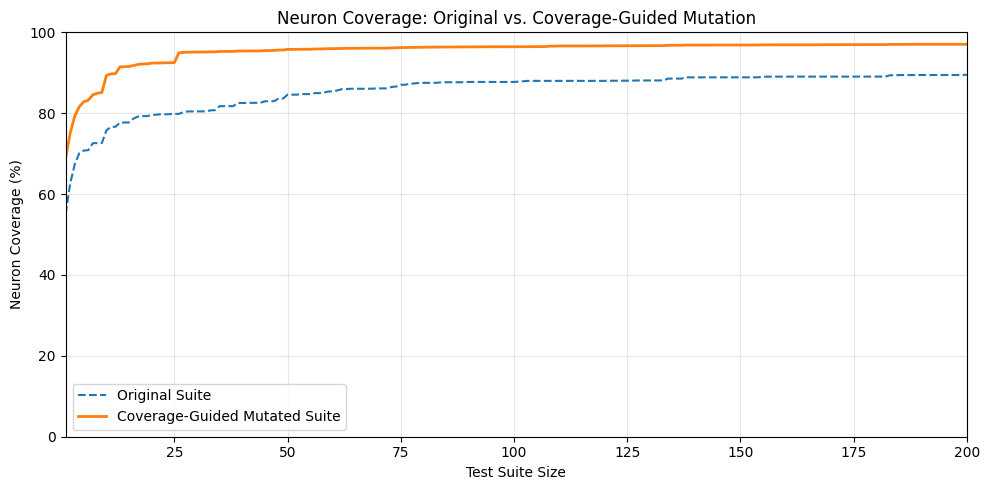

Coverage comparison:
  Final - Original: 89.5%, Mutated: 97.0% (Δ +7.5%)

Coverage at key points:
  Size  10: Original 75.7% → Mutated 89.3% (Δ +13.6%)
  Size  50: Original 84.6% → Mutated 95.8% (Δ +11.2%)
  Size 100: Original 87.7% → Mutated 96.4% (Δ +8.7%)
  Size 200: Original 89.5% → Mutated 97.0% (Δ +7.5%)


In [18]:
# Calculate and visualize neuron coverage: Original vs Coverage-Guided Mutated Suite
import matplotlib.pyplot as plt

max_size = len(test_images)
batch_sizes = list(range(1, max_size + 1))

# Calculate coverages for both suites
original_coverages = []
mutated_coverages = []

with torch.no_grad():
    for size in batch_sizes:
        # Original suite coverage
        orig_batch = test_images[:size].to(device)
        _, orig_acts = forward_and_capture_relu(model, orig_batch)
        orig_cov, _ = neuron_coverage(orig_acts)
        original_coverages.append(orig_cov)
        
        # Mutated suite coverage
        mut_batch = selected_inputs_tensor[:size].to(device)
        _, mut_acts = forward_and_capture_relu(model, mut_batch)
        mut_cov, _ = neuron_coverage(mut_acts)
        mutated_coverages.append(mut_cov)

# Plot comparison
plt.figure(figsize=(10, 5))
plt.plot(batch_sizes, [c * 100 for c in original_coverages], 
         linestyle="--", linewidth=1.5, color="tab:blue", label="Original Suite")
plt.plot(batch_sizes, [c * 100 for c in mutated_coverages], 
         linestyle="-", linewidth=2, color="tab:orange", label="Coverage-Guided Mutated Suite")
plt.xlabel("Test Suite Size")
plt.ylabel("Neuron Coverage (%)")
plt.title("Neuron Coverage: Original vs. Coverage-Guided Mutation")
plt.legend()
plt.grid(True, alpha=0.3)
plt.xlim(1, max_size)
plt.ylim(0, 100)
plt.tight_layout()
plt.show()

# Print summary
print("Coverage comparison:")
print(f"  Final - Original: {original_coverages[-1]:.1%}, Mutated: {mutated_coverages[-1]:.1%} (Δ {mutated_coverages[-1]-original_coverages[-1]:+.1%})")

print("\nCoverage at key points:")
for size in [10, 50, 100, 200]:
    if size <= max_size:
        idx = size - 1
        orig = original_coverages[idx]
        mut = mutated_coverages[idx]
        print(f"  Size {size:3d}: Original {orig:.1%} → Mutated {mut:.1%} (Δ {mut-orig:+.1%})")


## Test Suite Mutation Guided by Top-K Neuron Coverage

In [19]:
# Top-K Coverage-guided test input mutation
# For each test input, select the mutation that maximizes top-k neuron coverage increase

K_RATIO = 0.1  # Top 10%

# Track selected inputs and their mutation types
topk_selected_inputs = []
topk_selected_labels = []
topk_mutation_choices = []

with torch.no_grad():
    for idx in range(len(test_images)):
        original_img = test_images[idx]
        label = test_labels[idx]
        
        # Get current top-k coverage with selected inputs
        if len(topk_selected_inputs) > 0:
            current_batch = torch.stack(topk_selected_inputs).to(device)
            _, current_acts = forward_and_capture_relu(model, current_batch)
            current_cov, _ = top_k_neuron_coverage(current_acts, k=K_RATIO)
        else:
            current_cov = 0.0
        
        # Try each mutation and find the best one
        best_cov = current_cov
        best_img = original_img
        best_mutation = "Original"
        
        for name, mutation_fn in mutations:
            mutated_img = mutation_fn(original_img.clone())
            
            # Calculate top-k coverage with this candidate added
            if len(topk_selected_inputs) > 0:
                candidate_batch = torch.stack(topk_selected_inputs + [mutated_img]).to(device)
            else:
                candidate_batch = mutated_img.unsqueeze(0).to(device)
            
            _, candidate_acts = forward_and_capture_relu(model, candidate_batch)
            candidate_cov, _ = top_k_neuron_coverage(candidate_acts, k=K_RATIO)
            
            if candidate_cov > best_cov:
                best_cov = candidate_cov
                best_img = mutated_img
                best_mutation = name
        
        # Add the best input to our selected set
        topk_selected_inputs.append(best_img)
        topk_selected_labels.append(label)
        topk_mutation_choices.append(best_mutation)

# Convert to tensor
topk_selected_inputs_tensor = torch.stack(topk_selected_inputs)

print(f"Selected {len(topk_selected_inputs)} test inputs (Top-{K_RATIO:.0%} guided)")
print(f"\nMutation distribution:")
for name, _ in mutations:
    count = topk_mutation_choices.count(name)
    print(f"  - {name}: {count} ({100*count/len(topk_mutation_choices):.1f}%)")


Selected 200 test inputs (Top-10% guided)

Mutation distribution:
  - Original: 66 (33.0%)
  - Noise: 60 (30.0%)
  - Brightness: 7 (3.5%)
  - Rotation: 43 (21.5%)
  - Dropout: 24 (12.0%)


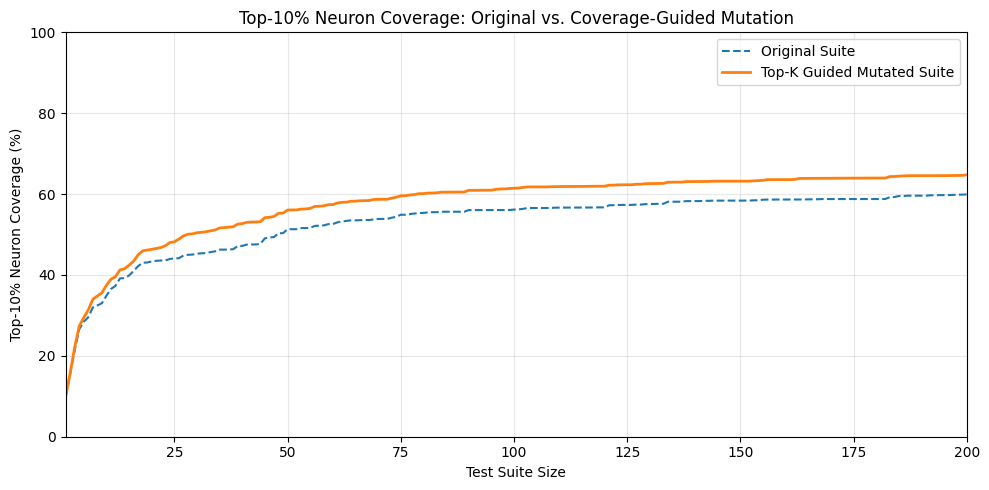

Top-10% Coverage comparison:
  Final - Original: 59.9%, Mutated: 64.8% (Δ +4.9%)

Coverage at key points:
  Size  10: Original 34.9% → Mutated 37.4% (Δ +2.6%)
  Size  50: Original 51.3% → Mutated 56.1% (Δ +4.7%)
  Size 100: Original 56.2% → Mutated 61.4% (Δ +5.3%)
  Size 200: Original 59.9% → Mutated 64.8% (Δ +4.9%)


In [20]:
# Calculate and visualize Top-K neuron coverage: Original vs Coverage-Guided Mutated Suite

max_size = len(test_images)
batch_sizes = list(range(1, max_size + 1))

# Calculate top-k coverages for both suites
topk_original_coverages = []
topk_mutated_coverages = []

with torch.no_grad():
    for size in batch_sizes:
        # Original suite coverage
        orig_batch = test_images[:size].to(device)
        _, orig_acts = forward_and_capture_relu(model, orig_batch)
        orig_cov, _ = top_k_neuron_coverage(orig_acts, k=K_RATIO)
        topk_original_coverages.append(orig_cov)
        
        # Top-K guided mutated suite coverage
        mut_batch = topk_selected_inputs_tensor[:size].to(device)
        _, mut_acts = forward_and_capture_relu(model, mut_batch)
        mut_cov, _ = top_k_neuron_coverage(mut_acts, k=K_RATIO)
        topk_mutated_coverages.append(mut_cov)

# Plot comparison
plt.figure(figsize=(10, 5))
plt.plot(batch_sizes, [c * 100 for c in topk_original_coverages], 
         linestyle="--", linewidth=1.5, color="tab:blue", label="Original Suite")
plt.plot(batch_sizes, [c * 100 for c in topk_mutated_coverages], 
         linestyle="-", linewidth=2, color="tab:orange", label="Top-K Guided Mutated Suite")
plt.xlabel("Test Suite Size")
plt.ylabel(f"Top-{K_RATIO:.0%} Neuron Coverage (%)")
plt.title(f"Top-{K_RATIO:.0%} Neuron Coverage: Original vs. Coverage-Guided Mutation")
plt.legend()
plt.grid(True, alpha=0.3)
plt.xlim(1, max_size)
plt.ylim(0, 100)
plt.tight_layout()
plt.show()

# Print summary
print(f"Top-{K_RATIO:.0%} Coverage comparison:")
print(f"  Final - Original: {topk_original_coverages[-1]:.1%}, Mutated: {topk_mutated_coverages[-1]:.1%} (Δ {topk_mutated_coverages[-1]-topk_original_coverages[-1]:+.1%})")

print("\nCoverage at key points:")
for size in [10, 50, 100, 200]:
    if size <= max_size:
        idx = size - 1
        orig = topk_original_coverages[idx]
        mut = topk_mutated_coverages[idx]
        print(f"  Size {size:3d}: Original {orig:.1%} → Mutated {mut:.1%} (Δ {mut-orig:+.1%})")


## 🏆 Challenge: Coverage-Maximizing Test Suite Competition

**Goal**: Generate a **50-input test suite** that achieves the **highest Top-10% Neuron Coverage**.

**Rules**:
| Constraint | Requirement |
|------------|-------------|
| **Suite Size** | Exactly 50 test inputs |
| **Source** | Derived from `test_images` (original or mutated) |
| **Metric** | Top-K Neuron Coverage (`k=0.1`) |


**You Can**:

- Define **custom mutation functions** (beyond noise, rotation, etc.)
- Design **custom test selection and minimization strategies** (greedy, random, diversity-based, etc.)
- Use any other creative approach!

Test suite minimization is NP-hard—you have limited time and computing budget. 

Propose your best heuristic solution and beat the others within **30 minutes**!